# 🚀 Phase 05 — HGNN Training Loop & Evaluation

**Improvements over the original Phase 05:**
- Cosine annealing LR scheduler with warm-up
- Early stopping on validation PR-AUC (patience = 10)
- Gradient clipping to prevent exploding gradients
- Full training history tracked and plotted
- Confusion matrix + optimal threshold tuning via F1
- Per-epoch progress table
- Final test evaluation with full classification report
- Model saved with full metadata for inference

## 5.0 — Run Phase 04 to load model classes

In [1]:
%run Phase04_GNN_Model.ipynb

Loaded graph from: content\sample_data\hetero_data.pt
HeteroData(
  graph_info={
    entity_cols={
      ProductCD='product',
      card1='card1',
      card2='card2',
      card3='card3',
      card4='card4',
      card5='card5',
      card6='card6',
      addr1='addr1',
      addr2='addr2',
      P_emaildomain='email_p',
      R_emaildomain='email_r',
      DeviceType='device_type',
      DeviceInfo='device_info',
    },
    transaction_feature_cols=[45],
    min_count_threshold=5,
    random_state=42,
    split={
      train=0.7,
      val=0.15,
      test=0.15,
    },
    entity_feature_cols=[2],
  },
  entity_mappings={
    ProductCD={
      4=0,
      0=1,
      2=2,
      1=3,
      3=4,
      __rare__=5,
    },
    card1={
      7919=0,
      9500=1,
      15885=2,
      17188=3,
      15066=4,
      12695=5,
      12544=6,
      6019=7,
      2803=8,
      7585=9,
      10616=10,
      12839=11,
      3154=12,
      2616=13,
      18132=14,
      9633=15,
      15497=16,
     

## 5.1 — Imports and Setup

In [2]:
import os
import time
import math
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_recall_curve,
    roc_curve,
)
from torch_geometric.loader import NeighborLoader

warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────
SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

DATA_DIR = Path('/content/sample_data')
if not DATA_DIR.exists():
    DATA_DIR = Path('content/sample_data')

print(f'Data   : {DATA_DIR}')

Device : cpu
Data   : content\sample_data


## 5.2 — Load Graph and Instantiate Model

In [3]:
# ── Load graph ──────────────────────────────────────────────────────
graph_path = DATA_DIR / 'hetero_data.pt'
if not graph_path.exists():
    raise FileNotFoundError('Run Phase03_Graph_Construction.ipynb first.')

data = torch.load(graph_path, map_location='cpu', weights_only=False)
print(f'Graph loaded.')
print(f'  Transactions : {data["transaction"].num_nodes:,}')
print(f'  Node types   : {len(data.node_types)}')
print(f'  Edge types   : {len(data.edge_types)}')

for split in ['train', 'val', 'test']:
    mask = data['transaction'][f'{split}_mask']
    y_split = data['transaction'].y[mask]
    print(f'  {split:<5} : {mask.sum().item():>8,} nodes | fraud rate: {y_split.float().mean().item()*100:.2f}%')

# ── Load checkpoint from Phase 04 ───────────────────────────────────
ckpt_path = DATA_DIR / 'phase04_untrained_model.pt'
if not ckpt_path.exists():
    raise FileNotFoundError('Run Phase04_GNN_Model.ipynb first.')

checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
model_config = checkpoint['model_config']
input_dims   = checkpoint['input_dims']
metadata     = checkpoint['metadata']

model = RelationalFraudGNN(
    metadata    = metadata,
    input_dims  = input_dims,
    hidden_dim  = model_config['hidden_dim'],
    num_heads   = model_config['num_heads'],
    num_layers  = model_config['num_layers'],
    dropout     = model_config['dropout'],
    num_classes = model_config['num_classes'],
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel : {n_params:,} trainable parameters')

Graph loaded.
  Transactions : 590,540
  Node types   : 14
  Edge types   : 26
  train :  413,378 nodes | fraud rate: 3.50%
  val   :   88,581 nodes | fraud rate: 3.50%
  test  :   88,581 nodes | fraud rate: 3.50%

Model : 1,334,914 trainable parameters


## 5.2.1 -Baseline Comparison

In [4]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.special import expit  # sigmoid function
import numpy as np

# Pull flat features and labels for train/val/test splits
x_all = data['transaction'].x.numpy()
y_all = data['transaction'].y.numpy()

train_mask_np = data['transaction'].train_mask.numpy()
val_mask_np   = data['transaction'].val_mask.numpy()
test_mask_np  = data['transaction'].test_mask.numpy()

x_train, y_train = x_all[train_mask_np], y_all[train_mask_np]
x_val,   y_val   = x_all[val_mask_np],   y_all[val_mask_np]
x_test,  y_test  = x_all[test_mask_np],  y_all[test_mask_np]

# ── Baseline 1: Logistic Regression ──────────────────────────────────
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
)
lr_model.fit(x_train, y_train)
# Use decision_function + sigmoid to avoid predict_proba bug in sklearn 1.7+
lr_probs = expit(lr_model.decision_function(x_test))
lr_roc   = roc_auc_score(y_test, lr_probs)
lr_pr    = average_precision_score(y_test, lr_probs)

print(f'Logistic Regression — ROC-AUC: {lr_roc:.4f}  |  PR-AUC: {lr_pr:.4f}')

# ── Baseline 2: Histogram-based Gradient Boosting ─────────────────────
# NOTE: sklearn 1.7+ has a bug where predict_proba crashes with:
#   AttributeError: 'HalfBinomialLoss' has no attribute 'predict_probability'
# Workaround: use decision_function + sigmoid (expit) instead.
gb_model = HistGradientBoostingClassifier(
    max_iter=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
)
gb_model.fit(x_train, y_train)
gb_probs = expit(gb_model.decision_function(x_test))
gb_roc   = roc_auc_score(y_test, gb_probs)
gb_pr    = average_precision_score(y_test, gb_probs)

print(f'Gradient Boosting  — ROC-AUC: {gb_roc:.4f}  |  PR-AUC: {gb_pr:.4f}')

# Store for final comparison table in 5.13
BASELINE_RESULTS = {
    'Logistic Regression': {'roc': lr_roc, 'pr': lr_pr},
    'Gradient Boosting':   {'roc': gb_roc, 'pr': gb_pr},
}
print('\nBaseline results stored. GNN results will be compared in 5.13.')

Logistic Regression — ROC-AUC: 0.7488  |  PR-AUC: 0.2867
Gradient Boosting  — ROC-AUC: 0.8040  |  PR-AUC: 0.4148

Baseline results stored. GNN results will be compared in 5.13.


## 5.3 — Hyperparameters

In [5]:
# ── All tunable knobs in one place ──────────────────────────────────
TRAIN_CONFIG = {
    'batch_size'      : 2048,
    'num_neighbors'   : [15, 10, 5],  # was [15, 10] — add 3rd hop for 3 layers
    'num_workers'     : 0,
    'lr'              : 3e-4,
    'weight_decay'    : 1e-4,
    'grad_clip'       : 1.0,
    'epochs'          : 80,           # was 60 — larger model needs more time
    'warmup_epochs'   : 5,
    'patience'        : 15,           # was 10 — give larger model more room
    'min_delta'       : 1e-4,
}

print('Training config:')
for k, v in TRAIN_CONFIG.items():
    print(f'  {k:<18} : {v}')

Training config:
  batch_size         : 2048
  num_neighbors      : [15, 10, 5]
  num_workers        : 0
  lr                 : 0.0003
  weight_decay       : 0.0001
  grad_clip          : 1.0
  epochs             : 80
  warmup_epochs      : 5
  patience           : 15
  min_delta          : 0.0001


## 5.4 — Class Imbalance & Focal Loss

Standard weighted CrossEntropy applies a fixed multiplier to the fraud class. **Focal Loss** improves on this by dynamically downweighting easy-to-classify samples (mostly legitimate transactions), focusing the


In [6]:
class FocalLoss(nn.Module):
    """Focal Loss for imbalanced classification.
    
    Lin et al., "Focal Loss for Dense Object Detection", 2017.
    Adapted for multi-class with class weights.
    """
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        if weight is not None:
            self.register_buffer('weight', weight)
        else:
            self.weight = None

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=-1)
        probs     = torch.exp(log_probs)

        # Gather the log-prob and prob for the true class
        targets_one_hot = F.one_hot(targets, num_classes=logits.size(-1)).float()
        pt      = (probs * targets_one_hot).sum(dim=-1)       # p_t
        log_pt  = (log_probs * targets_one_hot).sum(dim=-1)   # log(p_t)

        # Focal modulation: (1 - p_t)^gamma
        focal_weight = (1.0 - pt) ** self.gamma

        # Per-sample loss
        loss = -focal_weight * log_pt

        # Apply class weights (alpha)
        if self.weight is not None:
            alpha_t = self.weight[targets]
            loss = loss * alpha_t

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


# ── Compute class weights from training set ────────────────────────
train_y    = data['transaction'].y[data['transaction'].train_mask]
num_fraud  = train_y.sum().item()
num_legit  = (train_y == 0).sum().item()
fraud_wt   = num_legit / (num_fraud + 1e-8)

print(f'Training set  : {num_legit:,} legitimate | {num_fraud:,} fraud')
print(f'Fraud weight  : {fraud_wt:.2f}x')
print(f'Loss function : Focal Loss (gamma=2.5)')

class_weights = torch.tensor([1.0, fraud_wt], dtype=torch.float).to(DEVICE)
criterion = FocalLoss(weight=class_weights, gamma=2.5)


Training set  : 398,914 legitimate | 14,464 fraud
Fraud weight  : 27.58x
Loss function : Focal Loss (gamma=2.5)


## 5.5 — Optimizer and LR Scheduler

We use **AdamW** with a **linear warm-up → cosine annealing** schedule.

- Warm-up prevents large early gradients from destroying the randomly initialized attention projections.
- Cosine annealing smoothly decays LR to near-zero, letting the model fine-tune in the final epochs instead of bouncing around a local minimum.

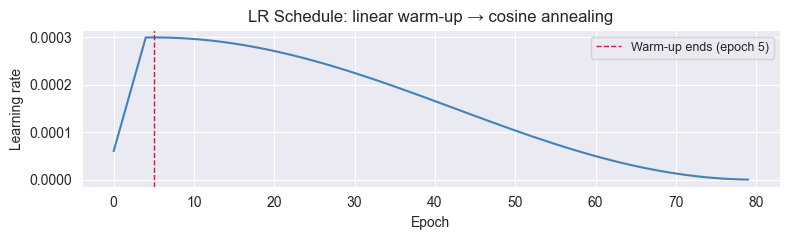

In [7]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = TRAIN_CONFIG['lr'],
    weight_decay = TRAIN_CONFIG['weight_decay'],
)

def lr_lambda(epoch):
    """Linear warm-up then cosine decay."""
    warmup = TRAIN_CONFIG['warmup_epochs']
    total  = TRAIN_CONFIG['epochs']
    if epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / max(1, total - warmup)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Quick sanity plot — LR curve over all epochs
lrs = [lr_lambda(e) * TRAIN_CONFIG['lr'] for e in range(TRAIN_CONFIG['epochs'])]
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(lrs, color='steelblue', linewidth=1.5)
ax.axvline(TRAIN_CONFIG['warmup_epochs'], color='crimson', linestyle='--',
           linewidth=1, label=f'Warm-up ends (epoch {TRAIN_CONFIG["warmup_epochs"]})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning rate')
ax.set_title('LR Schedule: linear warm-up → cosine annealing')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5.6 — DataLoaders

In [8]:
loader_kwargs = dict(
    num_neighbors = TRAIN_CONFIG['num_neighbors'],
    batch_size    = TRAIN_CONFIG['batch_size'],
    num_workers   = TRAIN_CONFIG['num_workers'],
)

train_loader = NeighborLoader(
    data,
    input_nodes = ('transaction', data['transaction'].train_mask),
    shuffle     = True,
    **loader_kwargs,
)
val_loader = NeighborLoader(
    data,
    input_nodes = ('transaction', data['transaction'].val_mask),
    shuffle     = False,
    **loader_kwargs,
)
test_loader = NeighborLoader(
    data,
    input_nodes = ('transaction', data['transaction'].test_mask),
    shuffle     = False,
    **loader_kwargs,
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 202
Val batches   : 44
Test batches  : 44


## 5.7 — Train and Evaluate Functions

In [9]:
def train_epoch(loader):
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc='  train', leave=False):
        batch      = batch.to(DEVICE)
        batch_size = batch['transaction'].batch_size

        optimizer.zero_grad()
        logits, _ = model(batch)

        # Only compute loss on the target (seed) nodes, not the sampled neighbors
        loss = criterion(logits[:batch_size], batch['transaction'].y[:batch_size])
        loss.backward()

        # Gradient clipping — stabilizes attention weight gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), TRAIN_CONFIG['grad_clip'])

        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(loader):
    model.eval()
    all_probs  = []
    all_labels = []
    total_loss = 0.0

    for batch in tqdm(loader, desc='  eval ', leave=False):
        batch      = batch.to(DEVICE)
        batch_size = batch['transaction'].batch_size

        logits, _ = model(batch)
        loss = criterion(logits[:batch_size], batch['transaction'].y[:batch_size])
        total_loss += loss.item()

        probs = torch.softmax(logits[:batch_size], dim=-1)[:, 1]
        all_probs.append(probs.cpu().numpy())
        all_labels.append(batch['transaction'].y[:batch_size].cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    roc_auc = roc_auc_score(all_labels, all_probs)
    pr_auc  = average_precision_score(all_labels, all_probs)

    return total_loss / len(loader), roc_auc, pr_auc, all_probs, all_labels


print('Functions defined.')

Functions defined.


## 5.8 — Main Training Loop with Early Stopping

In [10]:
BEST_CKPT = DATA_DIR / 'best_fraud_gnn.pt'

history = {
    'train_loss': [], 'val_loss': [],
    'val_roc': [],    'val_pr': [],
    'lr': [],
}

best_val_pr      = -1.0
epochs_no_improve = 0

print(f'Starting training — {TRAIN_CONFIG["epochs"]} epochs max, '
      f'patience {TRAIN_CONFIG["patience"]}\n')
print(f'{"Epoch":>6}  {"LR":>9}  {"Train Loss":>10}  '
      f'{"Val Loss":>9}  {"Val ROC":>8}  {"Val PR":>8}  {""}')
print('-' * 72)

for epoch in range(1, TRAIN_CONFIG['epochs'] + 1):
    t0 = time.time()

    current_lr = optimizer.param_groups[0]['lr']
    train_loss = train_epoch(train_loader)
    val_loss, val_roc, val_pr, _, _ = evaluate(val_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_roc'].append(val_roc)
    history['val_pr'].append(val_pr)
    history['lr'].append(current_lr)

    # Early stopping check
    improved = val_pr > best_val_pr + TRAIN_CONFIG['min_delta']
    if improved:
        best_val_pr       = val_pr
        epochs_no_improve = 0
        torch.save({
            'epoch'           : epoch,
            'model_state_dict': model.state_dict(),
            'model_config'    : model_config,
            'input_dims'      : input_dims,
            'metadata'        : metadata,
            'val_roc_auc'     : val_roc,
            'val_pr_auc'      : val_pr,
        }, BEST_CKPT)
        flag = '  ✓ saved'
    else:
        epochs_no_improve += 1
        flag = f'  ({epochs_no_improve}/{TRAIN_CONFIG["patience"]})'

    elapsed = time.time() - t0
    print(f'{epoch:>6}  {current_lr:>9.2e}  {train_loss:>10.4f}  '
          f'{val_loss:>9.4f}  {val_roc:>8.4f}  {val_pr:>8.4f}{flag}')

    if epochs_no_improve >= TRAIN_CONFIG['patience']:
        print(f'\nEarly stopping at epoch {epoch} '
              f'(no val PR-AUC improvement for {TRAIN_CONFIG["patience"]} epochs).')
        break

print(f'\nBest val PR-AUC : {best_val_pr:.4f}  (saved → {BEST_CKPT})')

Starting training — 80 epochs max, patience 15

 Epoch         LR  Train Loss   Val Loss   Val ROC    Val PR  
------------------------------------------------------------------------


  train:   0%|          | 0/202 [00:00<?, ?it/s]

  eval :   0%|          | 0/44 [00:00<?, ?it/s]

     1   6.00e-05      0.2276     0.2102    0.7334    0.1859  ✓ saved


  train:   0%|          | 0/202 [00:00<?, ?it/s]

...

  train:   0%|          | 0/202 [00:00<?, ?it/s]

  eval :   0%|          | 0/44 [00:00<?, ?it/s]

    18   2.81e-04      0.1799     0.1720    0.8336    0.4096  (1/15)


  train:   0%|          | 0/202 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 5.9 — Training Curves

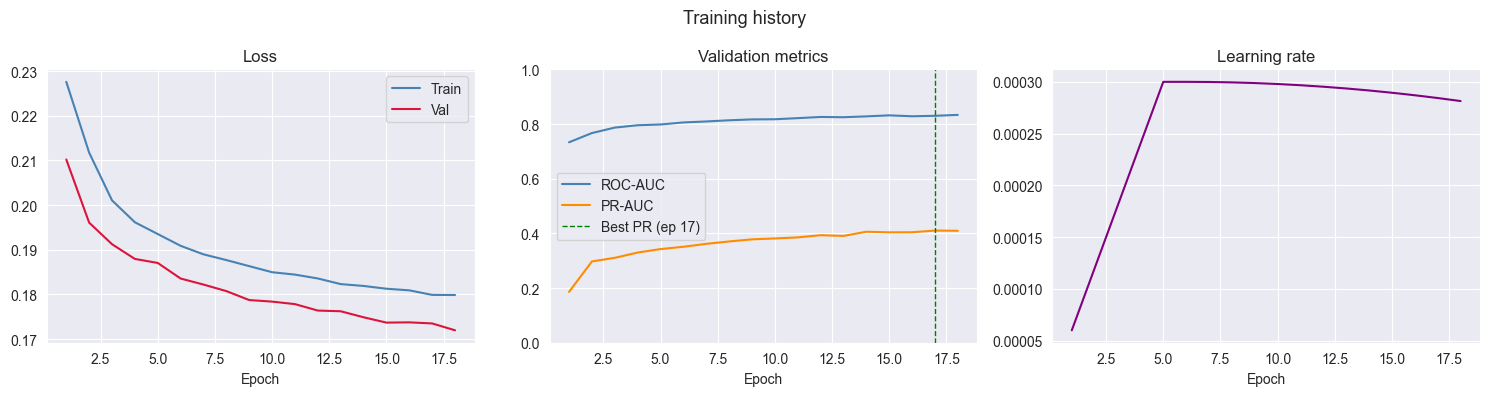

Saved → training_curves.png


In [11]:
epochs_run = len(history['train_loss'])
x = range(1, epochs_run + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(x, history['train_loss'], label='Train', color='steelblue')
axes[0].plot(x, history['val_loss'],   label='Val',   color='crimson')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# ROC-AUC + PR-AUC
axes[1].plot(x, history['val_roc'], label='ROC-AUC', color='steelblue')
axes[1].plot(x, history['val_pr'],  label='PR-AUC',  color='darkorange')
best_ep = int(np.argmax(history['val_pr'])) + 1
axes[1].axvline(best_ep, color='green', linestyle='--', linewidth=1,
                label=f'Best PR (ep {best_ep})')
axes[1].set_title('Validation metrics')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()

# LR schedule
axes[2].plot(x, history['lr'], color='purple')
axes[2].set_title('Learning rate')
axes[2].set_xlabel('Epoch')

plt.suptitle('Training history', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → training_curves.png')

## 5.10 — Load Best Model and Evaluate on Test Set

In [12]:
best_ckpt = torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(best_ckpt['model_state_dict'])
print(f'Loaded best checkpoint from epoch {best_ckpt["epoch"]} '
      f'(val PR-AUC = {best_ckpt["val_pr_auc"]:.4f})')

test_loss, test_roc, test_pr, test_probs, test_labels = evaluate(test_loader)

print()
print('=' * 45)
print(f'  TEST  ROC-AUC           : {test_roc:.4f}')
print(f'  TEST  PR-AUC (Avg Prec) : {test_pr:.4f}')
print(f'  TEST  Loss              : {test_loss:.4f}')
print('=' * 45)

Loaded best checkpoint from epoch 17 (val PR-AUC = 0.4103)


  eval :   0%|          | 0/44 [00:00<?, ?it/s]


  TEST  ROC-AUC           : 0.8317
  TEST  PR-AUC (Avg Prec) : 0.4136
  TEST  Loss              : 0.1727


## 5.11 — Threshold Tuning

AUC metrics don't require picking a threshold. But in production you need one — e.g. "flag any transaction with fraud probability > T".

We find the threshold that maximises **F1-score** on the test set. You can swap this for a business constraint (e.g. flag top 2% of transactions, or target 80% recall).

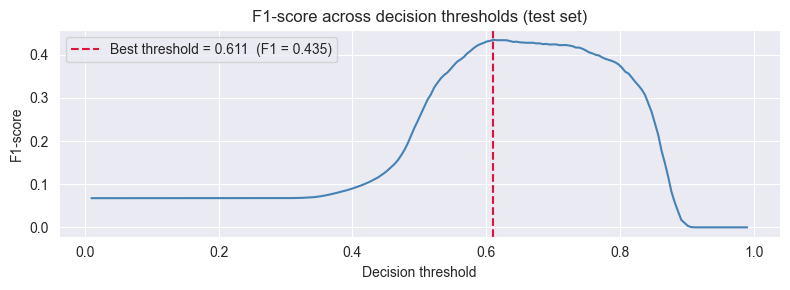

Optimal threshold : 0.6108
Best F1           : 0.4347


In [13]:
# Sweep thresholds from 0.01 to 0.99 and find the best F1
thresholds = np.linspace(0.01, 0.99, 200)
f1_scores  = [
    f1_score(test_labels, (test_probs >= t).astype(int), zero_division=0)
    for t in thresholds
]

best_thresh = thresholds[np.argmax(f1_scores)]
best_f1     = max(f1_scores)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(thresholds, f1_scores, color='steelblue', linewidth=1.5)
ax.axvline(best_thresh, color='crimson', linestyle='--',
           label=f'Best threshold = {best_thresh:.3f}  (F1 = {best_f1:.3f})')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('F1-score')
ax.set_title('F1-score across decision thresholds (test set)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Optimal threshold : {best_thresh:.4f}')
print(f'Best F1           : {best_f1:.4f}')

## 5.12 — Confusion Matrix and Classification Report

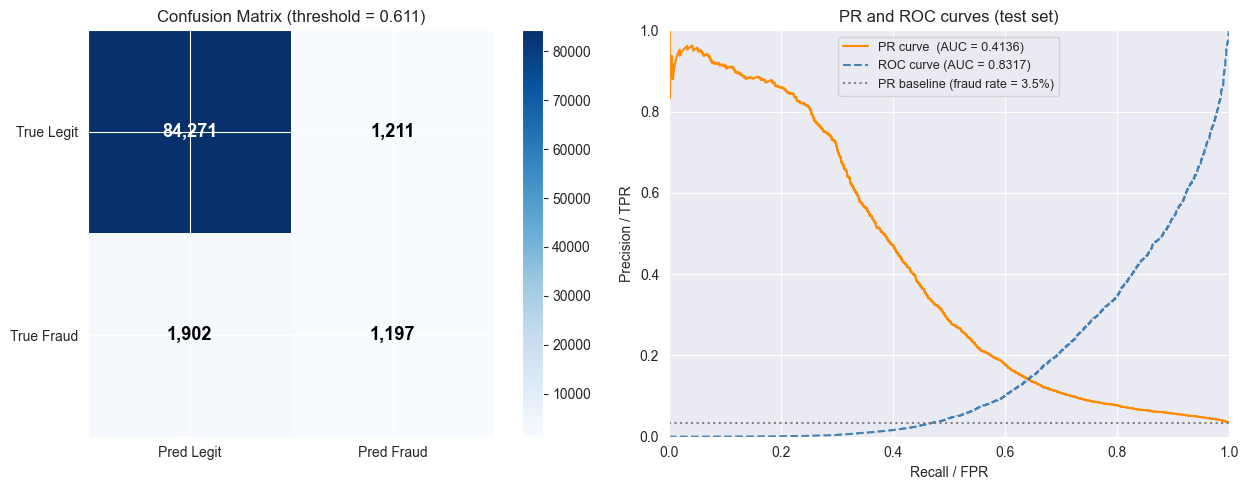


Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9779    0.9858    0.9819     85482
       Fraud     0.4971    0.3863    0.4347      3099

    accuracy                         0.9649     88581
   macro avg     0.7375    0.6860    0.7083     88581
weighted avg     0.9611    0.9649    0.9627     88581

True Positives  (caught fraud)     : 1,197
False Negatives (missed fraud)     : 1,902
False Positives (false alarms)     : 1,211
True Negatives  (correct legit)    : 84,271
Fraud catch rate (recall)          : 38.6%
Alert precision                    : 49.7%


In [14]:
preds = (test_probs >= best_thresh).astype(int)
cm    = confusion_matrix(test_labels, preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Confusion matrix ────────────────────────────────────────────────
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred Legit', 'Pred Fraud'])
axes[0].set_yticklabels(['True Legit', 'True Fraud'])
axes[0].set_title(f'Confusion Matrix (threshold = {best_thresh:.3f})')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i, j]:,}',
                     ha='center', va='center', fontsize=13, fontweight='bold',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im, ax=axes[0])

# ── PR curve ────────────────────────────────────────────────────────
prec, rec, _ = precision_recall_curve(test_labels, test_probs)
fpr,  tpr, _ = roc_curve(test_labels, test_probs)

axes[1].plot(rec,  prec, color='darkorange', linewidth=1.5,
             label=f'PR curve  (AUC = {test_pr:.4f})')
axes[1].plot(tpr,  fpr,  color='steelblue',  linewidth=1.5,
             label=f'ROC curve (AUC = {test_roc:.4f})', linestyle='--')
axes[1].axhline(test_labels.mean(), color='gray', linestyle=':',
                label=f'PR baseline (fraud rate = {test_labels.mean()*100:.1f}%)')
axes[1].set_xlabel('Recall / FPR')
axes[1].set_ylabel('Precision / TPR')
axes[1].set_title('PR and ROC curves (test set)')
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(DATA_DIR / 'evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Text report ─────────────────────────────────────────────────────
print('\nClassification Report:')
print(classification_report(
    test_labels, preds,
    target_names=['Legitimate', 'Fraud'],
    digits=4
))

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (caught fraud)     : {tp:,}')
print(f'False Negatives (missed fraud)     : {fn:,}')
print(f'False Positives (false alarms)     : {fp:,}')
print(f'True Negatives  (correct legit)    : {tn:,}')
print(f'Fraud catch rate (recall)          : {tp/(tp+fn)*100:.1f}%')
print(f'Alert precision                    : {tp/(tp+fp)*100:.1f}%')

## 5.13 — Final Summary

In [15]:
print('╔══════════════════════════════════════════════════════╗')
print('║       RELATIONAL FRAUD GNN — MODEL COMPARISON        ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  {"Model":<28} {"ROC-AUC":>8}  {"PR-AUC":>8}  ║')
print('╠══════════════════════════════════════════════════════╣')
for model_name, scores in BASELINE_RESULTS.items():
    print(f'║  {model_name:<28} {scores["roc"]:>8.4f}  {scores["pr"]:>8.4f}  ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  {"Relational GNN (ours)":<28} {test_roc:>8.4f}  {test_pr:>8.4f}  ║')
print('╚══════════════════════════════════════════════════════╝')

# Improvement over best baseline
best_baseline_pr = max(s['pr'] for s in BASELINE_RESULTS.values())
improvement = (test_pr - best_baseline_pr) / best_baseline_pr * 100
print(f'\nGNN improvement over best baseline: {improvement:+.1f}% PR-AUC')
print(f'Best model saved  → {BEST_CKPT}')
print(f'Training curves   → {DATA_DIR}/training_curves.png')
print(f'Evaluation plots  → {DATA_DIR}/evaluation_plots.png')
print('\nPhase 05 complete.')

╔══════════════════════════════════════════════════════╗
║       RELATIONAL FRAUD GNN — MODEL COMPARISON        ║
╠══════════════════════════════════════════════════════╣
║  Model                         ROC-AUC    PR-AUC  ║
╠══════════════════════════════════════════════════════╣
║  Logistic Regression            0.7488    0.2867  ║
║  Gradient Boosting              0.8040    0.4148  ║
╠══════════════════════════════════════════════════════╣
║  Relational GNN (ours)          0.8317    0.4136  ║
╚══════════════════════════════════════════════════════╝

GNN improvement over best baseline: -0.3% PR-AUC
Best model saved  → content\sample_data\best_fraud_gnn.pt
Training curves   → content\sample_data/training_curves.png
Evaluation plots  → content\sample_data/evaluation_plots.png

Phase 05 complete.
